In [4]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn imports
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# Model imports
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
# Load the dataset
data = pd.read_csv(r'C:\Users\aiman\Desktop\SamsungInnovationCAMPUS\Datasets\adult.csv')
print(f"Dataset loaded successfully!")
print(f"Shape: {data.shape}")
data.head()

Dataset loaded successfully!
Shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


Target Variable: income

Target Variable Distribution:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Target Variable Proportions:
income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64


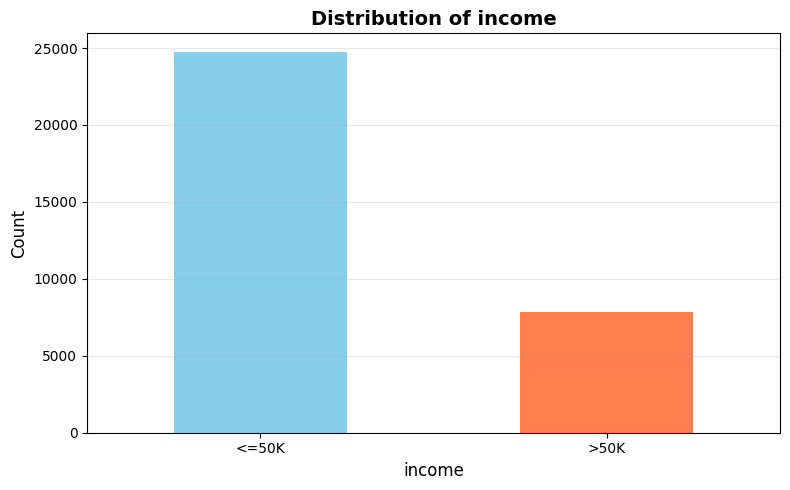

In [6]:
# Target variable distribution (income)
# Assuming the target variable is named 'income' or similar
target_col = [col for col in data.columns if 'income' in col.lower()]
if target_col:
    target_col = target_col[0]
else:
    # Check last column (common practice)
    target_col = data.columns[-1]

print(f"Target Variable: {target_col}")
print("\nTarget Variable Distribution:")
print(data[target_col].value_counts())
print("\nTarget Variable Proportions:")
print(data[target_col].value_counts(normalize=True))

# Visualization
plt.figure(figsize=(8, 5))
data[target_col].value_counts().plot(kind='bar', color=['skyblue', 'coral'])
plt.title(f'Distribution of {target_col}', fontsize=14, fontweight='bold')
plt.xlabel(target_col, fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

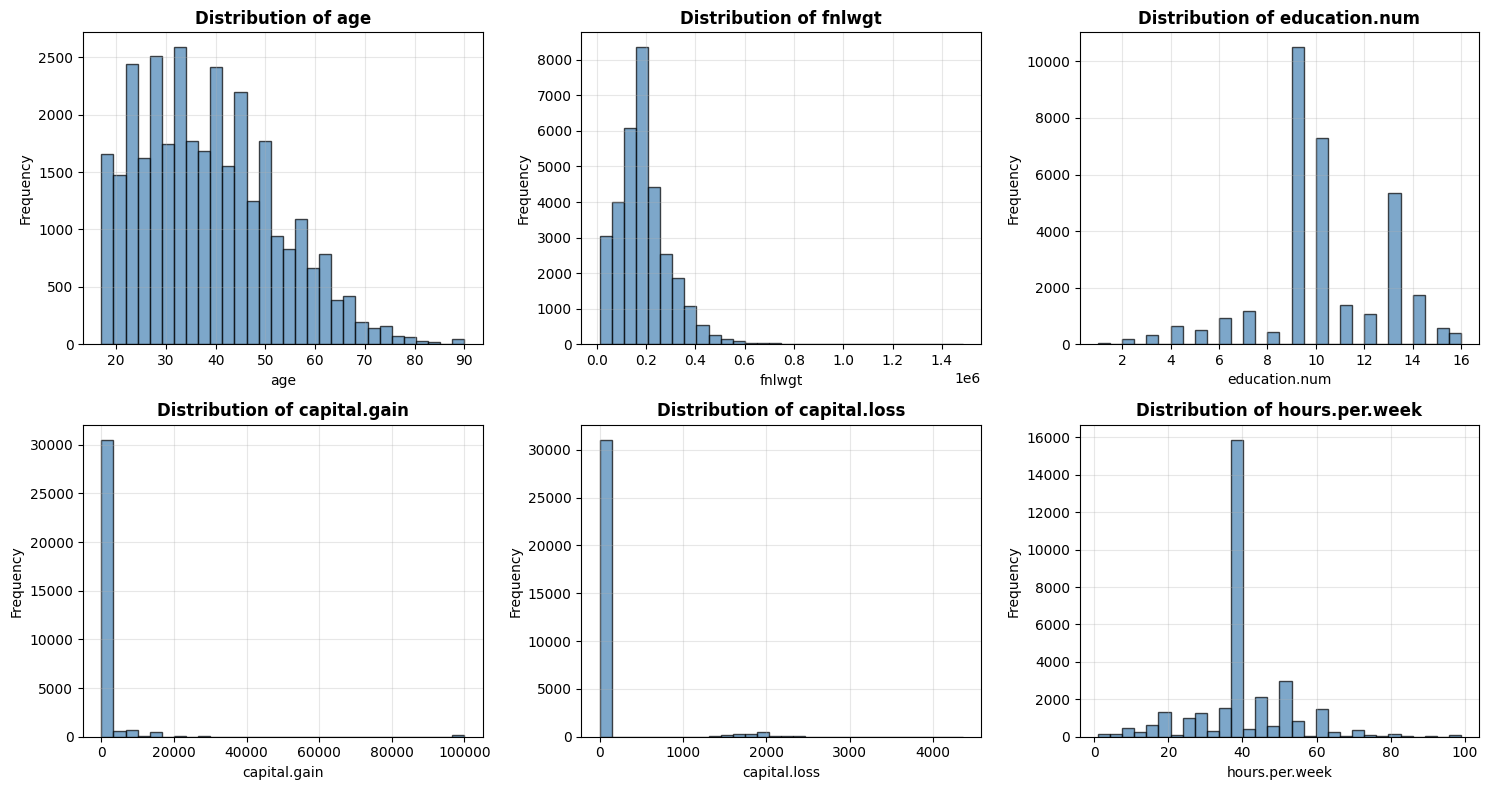

In [7]:
# Distribution of numerical features
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
if target_col in numerical_cols:
    numerical_cols.remove(target_col)

if len(numerical_cols) > 0:
    n_cols = min(3, len(numerical_cols))
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if len(numerical_cols) > 1 else [axes]
    
    for idx, col in enumerate(numerical_cols):
        axes[idx].hist(data[col].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(alpha=0.3)
    
    # Hide extra subplots
    for idx in range(len(numerical_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

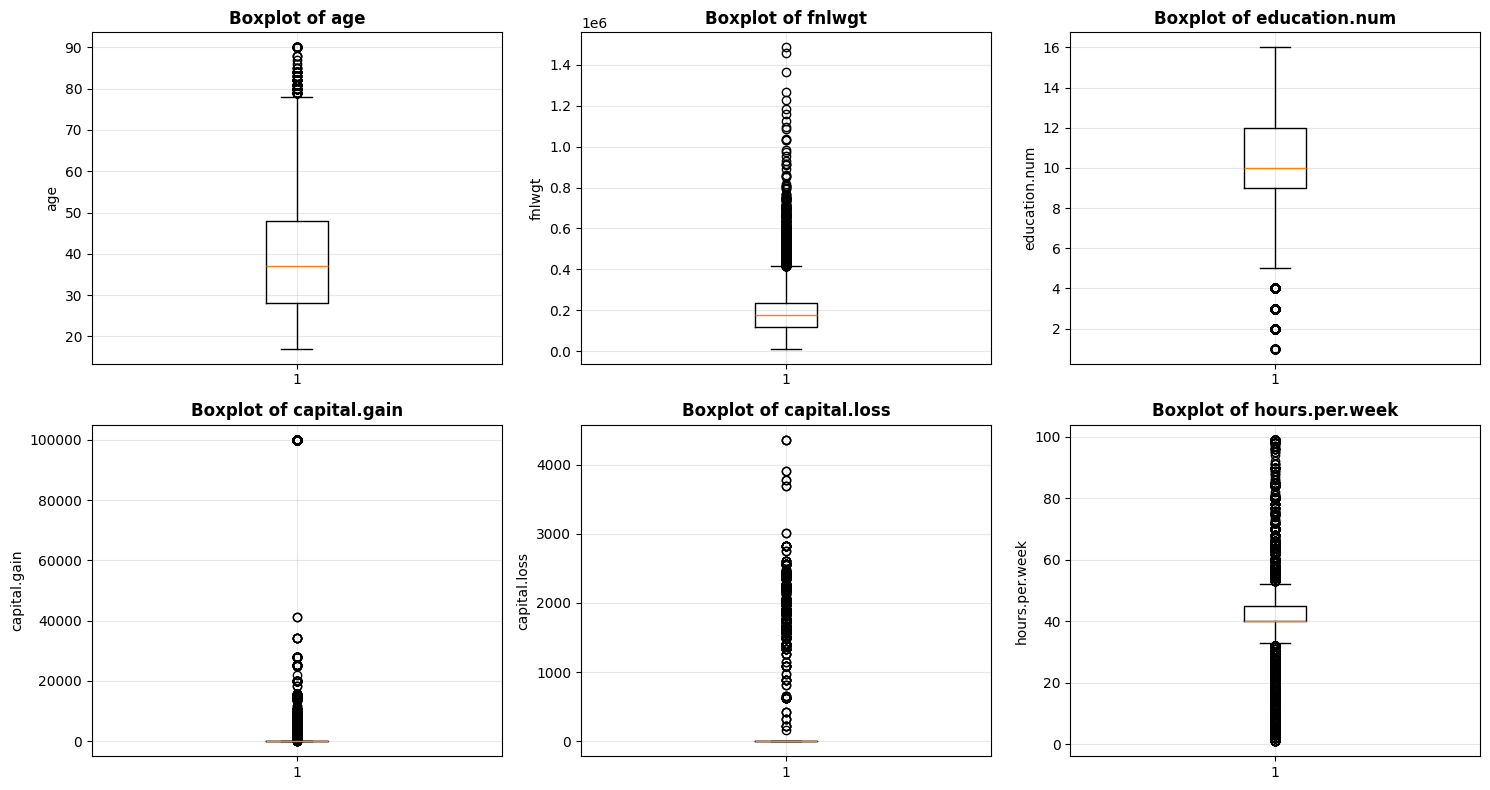

In [8]:
# Boxplots to detect outliers
if len(numerical_cols) > 0:
    n_cols = min(3, len(numerical_cols))
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if len(numerical_cols) > 1 else [axes]
    
    for idx, col in enumerate(numerical_cols):
        axes[idx].boxplot(data[col].dropna(), vert=True)
        axes[idx].set_title(f'Boxplot of {col}', fontweight='bold')
        axes[idx].set_ylabel(col)
        axes[idx].grid(alpha=0.3)
    
    # Hide extra subplots
    for idx in range(len(numerical_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Data Preprocessing

In [9]:
# Statistical summary
print("Statistical Summary for Numerical Features:")
print(data.describe())
print("\n" + "=" * 60)
print("Statistical Summary for Categorical Features:")
print(data.describe(include=['object']))

Statistical Summary for Numerical Features:
                age        fnlwgt  education.num  capital.gain  capital.loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours.per.week  
count    32561.000000  
mean        40.437456  
std         12.347429  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  

Statistical Summar

In [10]:
# Basic dataset information
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
print(f"\nDataset Shape: {data.shape}")
print(f"Number of Samples: {data.shape[0]}")
print(f"Number of Features: {data.shape[1]}")
print("\nColumn Names and Data Types:")
print(data.dtypes)
print("\nMissing Values:")
print(data.isnull().sum())
print("\nDuplicate Rows:", data.duplicated().sum())

DATASET INFORMATION

Dataset Shape: (32561, 15)
Number of Samples: 32561
Number of Features: 15

Column Names and Data Types:
age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object

Missing Values:
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

Duplicate Rows: 24


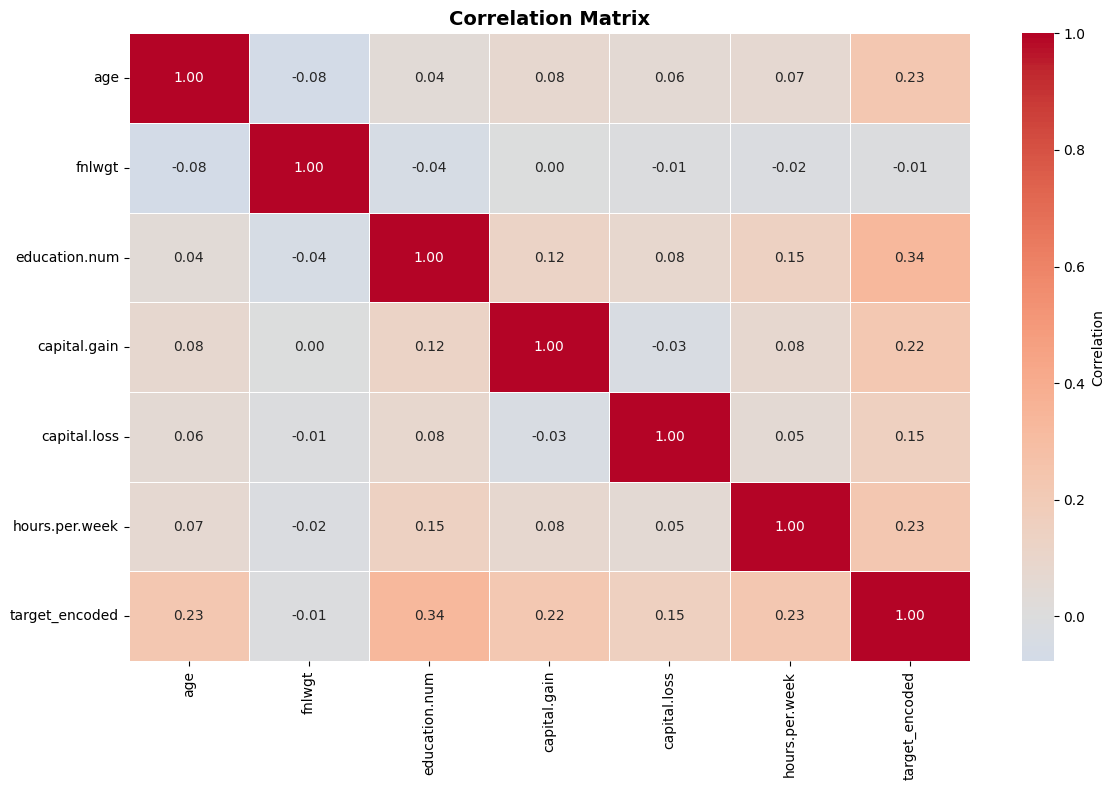


Correlation with Target Variable:
target_encoded    1.000000
education.num     0.335154
age               0.234037
hours.per.week    0.229689
capital.gain      0.223329
capital.loss      0.150526
fnlwgt           -0.009463
Name: target_encoded, dtype: float64


In [11]:
# Correlation analysis
if len(numerical_cols) > 0:
    # Create a copy with encoded target for correlation
    correlation_data = data[numerical_cols].copy()
    
    # Encode target if it's categorical
    if data[target_col].dtype == 'object':
        le_temp = LabelEncoder()
        correlation_data['target_encoded'] = le_temp.fit_transform(data[target_col])
    else:
        correlation_data['target_encoded'] = data[target_col]
    
    # Calculate correlation matrix
    correlation_matrix = correlation_data.corr()
    
    # Visualize correlation matrix
    plt.figure(figsize=(12, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Correlation'})
    plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Show correlation with target
    print("\nCorrelation with Target Variable:")
    print(correlation_matrix['target_encoded'].sort_values(ascending=False))

In [ ]:
data.info()

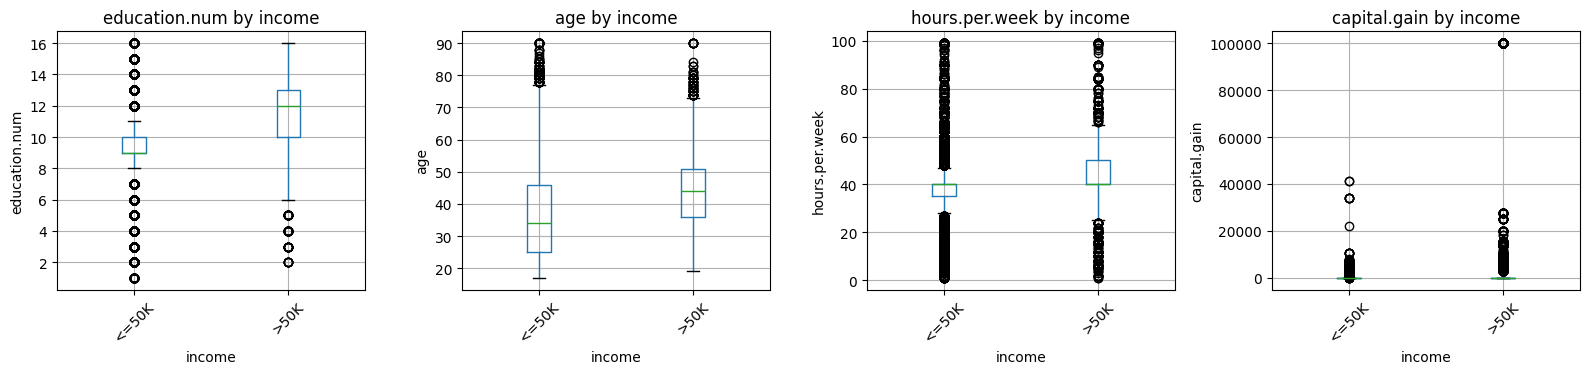

In [12]:
# Relationship between features and target (for key numeric features)
if len(numerical_cols) > 0:
    # Select top correlated features (up to 4)
    top_features = correlation_matrix['target_encoded'].abs().sort_values(ascending=False)[1:5].index.tolist()
    
    if len(top_features) > 0:
        n_features = len(top_features)
        fig, axes = plt.subplots(1, min(n_features, 4), figsize=(16, 4))
        axes = axes.flatten() if n_features > 1 else [axes]
        
        for idx, feature in enumerate(top_features[:4]):
            data.boxplot(column=feature, by=target_col, ax=axes[idx])
            axes[idx].set_title(f'{feature} by {target_col}')
            axes[idx].set_xlabel(target_col)
            axes[idx].set_ylabel(feature)
            plt.sca(axes[idx])
            plt.xticks(rotation=45)
        
        plt.suptitle('')  # Remove the default title
        plt.tight_layout()
        plt.show()

In [13]:
# Prepare data for modeling
# Create a copy
df = data.copy()

# Handle missing values if any (using mode for categorical, median for numerical)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

# Remove any whitespace from string columns
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
0


In [14]:
# Separate features and target
X = df.drop(target_col, axis=1)
y = df[target_col]

# Encode categorical variables
label_encoders = {}
categorical_columns = X.select_dtypes(include=['object']).columns

for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Encode target variable
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

print(f"Feature matrix shape: {X.shape}")
print(f"Target variable shape: {y_encoded.shape}")
print(f"Target classes: {le_target.classes_}")

Feature matrix shape: (32561, 14)
Target variable shape: (32561,)
Target classes: ['<=50K' '>50K']


In [15]:
# Helper function to evaluate models
def evaluate_model(y_true, y_pred, model_name):
    """Evaluate a model and print metrics"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    print(f"\n{'='*60}")
    print(f"{model_name} - EVALUATION METRICS")
    print(f"{'='*60}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=le_target.classes_))
    
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

# Dictionary to store results
results = []

In [16]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Training set proportion: {X_train.shape[0] / len(X) * 100:.1f}%")
print(f"Test set proportion: {X_test.shape[0] / len(X) * 100:.1f}%")

# Check class distribution
print("\nClass distribution in training set:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {le_target.classes_[cls]}: {cnt} ({cnt/len(y_train)*100:.1f}%)")

Training set size: 26048 samples
Test set size: 6513 samples
Training set proportion: 80.0%
Test set proportion: 20.0%

Class distribution in training set:
  Class <=50K: 19775 (75.9%)
  Class >50K: 6273 (24.1%)


In [17]:
# Feature scaling (important for distance-based algorithms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print(f"Scaled training data mean: {X_train_scaled.mean():.6f}")
print(f"Scaled training data std: {X_train_scaled.std():.6f}")

Feature scaling completed!
Scaled training data mean: 0.000000
Scaled training data std: 1.000000


## 6. Random Forest

In [18]:
# Random Forest with hyperparameter tuning
print("Training Random Forest with GridSearchCV...")

# Define parameter grid
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid search
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)  # Random Forest works well without scaling

# Best model
rf_best = rf_grid.best_estimator_
print(f"\nBest parameters: {rf_grid.best_params_}")
print(f"Best cross-validation score: {rf_grid.best_score_:.4f}")

# Predictions
y_pred_rf = rf_best.predict(X_test)

# Evaluation
rf_results = evaluate_model(y_test, y_pred_rf, "Random Forest")
results.append(rf_results)

Training Random Forest with GridSearchCV...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Best cross-validation score: 0.8659

Random Forest - EVALUATION METRICS
Accuracy:  0.8612
Precision: 0.8554
Recall:    0.8612
F1-Score:  0.8552

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91      4945
        >50K       0.77      0.61      0.68      1568

    accuracy                           0.86      6513
   macro avg       0.83      0.77      0.79      6513
weighted avg       0.86      0.86      0.86      6513



## 5. Support Vector Machine (SVM)

In [19]:
# Support Vector Machine with hyperparameter tuning
print("Training Support Vector Machine with GridSearchCV...")

# Define parameter grid
svm_params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

# Grid search
svm_grid = GridSearchCV(
    SVC(random_state=42),
    svm_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train_scaled, y_train)

# Best model
svm_best = svm_grid.best_estimator_
print(f"\nBest parameters: {svm_grid.best_params_}")
print(f"Best cross-validation score: {svm_grid.best_score_:.4f}")

# Predictions
y_pred_svm = svm_best.predict(X_test_scaled)

# Evaluation
svm_results = evaluate_model(y_test, y_pred_svm, "Support Vector Machine")
results.append(svm_results)

Training Support Vector Machine with GridSearchCV...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation score: 0.8483

Support Vector Machine - EVALUATION METRICS
Accuracy:  0.8472
Precision: 0.8396
Recall:    0.8472
F1-Score:  0.8382

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.87      0.94      0.90      4945
        >50K       0.75      0.55      0.63      1568

    accuracy                           0.85      6513
   macro avg       0.81      0.74      0.77      6513
weighted avg       0.84      0.85      0.84      6513



## 4. K-Nearest Neighbors (KNN)

In [20]:
# K-Nearest Neighbors with hyperparameter tuning
print("Training K-Nearest Neighbors with GridSearchCV...")

# Define parameter grid
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Grid search
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

knn_grid.fit(X_train_scaled, y_train)

# Best model
knn_best = knn_grid.best_estimator_
print(f"\nBest parameters: {knn_grid.best_params_}")
print(f"Best cross-validation score: {knn_grid.best_score_:.4f}")

# Predictions
y_pred_knn = knn_best.predict(X_test_scaled)

# Evaluation
knn_results = evaluate_model(y_test, y_pred_knn, "K-Nearest Neighbors")
results.append(knn_results)

Training K-Nearest Neighbors with GridSearchCV...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
Best cross-validation score: 0.8376

K-Nearest Neighbors - EVALUATION METRICS
Accuracy:  0.8383
Precision: 0.8315
Recall:    0.8383
F1-Score:  0.8333

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.87      0.92      0.90      4945
        >50K       0.70      0.58      0.64      1568

    accuracy                           0.84      6513
   macro avg       0.78      0.75      0.77      6513
weighted avg       0.83      0.84      0.83      6513



## 3. Naive Bayes

In [21]:
# Naive Bayes (Gaussian)
# Note: Gaussian Naive Bayes has limited hyperparameters
print("Training Naive Bayes...")

# Define parameter grid
nb_params = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

# Grid search
nb_grid = GridSearchCV(
    GaussianNB(),
    nb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

nb_grid.fit(X_train_scaled, y_train)

# Best model
nb_best = nb_grid.best_estimator_
print(f"\nBest parameters: {nb_grid.best_params_}")
print(f"Best cross-validation score: {nb_grid.best_score_:.4f}")

# Predictions
y_pred_nb = nb_best.predict(X_test_scaled)

# Evaluation
nb_results = evaluate_model(y_test, y_pred_nb, "Naive Bayes")
results.append(nb_results)

Training Naive Bayes...
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best parameters: {'var_smoothing': 1e-09}
Best cross-validation score: 0.8056

Naive Bayes - EVALUATION METRICS
Accuracy:  0.8027
Precision: 0.7863
Recall:    0.8027
F1-Score:  0.7760

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.82      0.95      0.88      4945
        >50K       0.69      0.33      0.45      1568

    accuracy                           0.80      6513
   macro avg       0.75      0.64      0.66      6513
weighted avg       0.79      0.80      0.78      6513



## 2. Decision Tree

In [22]:
# Decision Tree with hyperparameter tuning
print("Training Decision Tree with GridSearchCV...")

# Define parameter grid
dt_params = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Grid search
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)  # Decision trees don't require scaling

# Best model
dt_best = dt_grid.best_estimator_
print(f"\nBest parameters: {dt_grid.best_params_}")
print(f"Best cross-validation score: {dt_grid.best_score_:.4f}")

# Predictions
y_pred_dt = dt_best.predict(X_test)

# Evaluation
dt_results = evaluate_model(y_test, y_pred_dt, "Decision Tree")
results.append(dt_results)

Training Decision Tree with GridSearchCV...
Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best cross-validation score: 0.8543

Decision Tree - EVALUATION METRICS
Accuracy:  0.8481
Precision: 0.8433
Recall:    0.8481
F1-Score:  0.8449

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.90      4945
        >50K       0.71      0.63      0.67      1568

    accuracy                           0.85      6513
   macro avg       0.80      0.77      0.78      6513
weighted avg       0.84      0.85      0.84      6513



## 1. Logistic Regression

In [23]:
# Logistic Regression with hyperparameter tuning
print("Training Logistic Regression with GridSearchCV...")

# Define parameter grid
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [1000]
}

# Grid search
lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train_scaled, y_train)

# Best model
lr_best = lr_grid.best_estimator_
print(f"\nBest parameters: {lr_grid.best_params_}")
print(f"Best cross-validation score: {lr_grid.best_score_:.4f}")

# Predictions
y_pred_lr = lr_best.predict(X_test_scaled)

# Evaluation
lr_results = evaluate_model(y_test, y_pred_lr, "Logistic Regression")
results.append(lr_results)

Training Logistic Regression with GridSearchCV...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best parameters: {'C': 100, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Best cross-validation score: 0.8246

Logistic Regression - EVALUATION METRICS
Accuracy:  0.8270
Precision: 0.8161
Recall:    0.8270
F1-Score:  0.8122

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.85      0.94      0.89      4945
        >50K       0.72      0.46      0.56      1568

    accuracy                           0.83      6513
   macro avg       0.78      0.70      0.73      6513
weighted avg       0.82      0.83      0.81      6513



In [24]:
# Create comparison DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)
print(results_df.to_string(index=False))
print("=" * 80)

# Identify best model
best_model = results_df.iloc[0]['Model']
best_accuracy = results_df.iloc[0]['Accuracy']
print(f"\n🏆 BEST MODEL: {best_model}")
print(f"   Accuracy: {best_accuracy:.4f}")
print(f"   Precision: {results_df.iloc[0]['Precision']:.4f}")
print(f"   Recall: {results_df.iloc[0]['Recall']:.4f}")
print(f"   F1-Score: {results_df.iloc[0]['F1-Score']:.4f}")

MODEL PERFORMANCE COMPARISON
                 Model  Accuracy  Precision   Recall  F1-Score
         Random Forest  0.861201   0.855370 0.861201  0.855195
         Decision Tree  0.848150   0.843269 0.848150  0.844904
Support Vector Machine  0.847229   0.839592 0.847229  0.838248
   K-Nearest Neighbors  0.838323   0.831463 0.838323  0.833336
   Logistic Regression  0.826961   0.816060 0.826961  0.812155
           Naive Bayes  0.802702   0.786321 0.802702  0.775963

🏆 BEST MODEL: Random Forest
   Accuracy: 0.8612
   Precision: 0.8554
   Recall: 0.8612
   F1-Score: 0.8552


In [25]:
# Save the best model for future use
import pickle

# Determine which model is best and save it
best_model_name = results_df.iloc[0]['Model']

# Map model names to their trained instances
model_mapping = {
    'Logistic Regression': lr_best,
    'Decision Tree': dt_best,
    'Naive Bayes': nb_best,
    'K-Nearest Neighbors': knn_best,
    'Support Vector Machine': svm_best,
    'Random Forest': rf_best
}

best_model_instance = model_mapping[best_model_name]

# Save the model
model_filename = f'best_model_{best_model_name.replace(" ", "_").lower()}.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_model_instance, file)

# Also save the scaler if the model requires scaling
if best_model_name in ['Logistic Regression', 'K-Nearest Neighbors', 'Support Vector Machine', 'Naive Bayes']:
    scaler_filename = 'scaler.pkl'
    with open(scaler_filename, 'wb') as file:
        pickle.dump(scaler, file)
    print(f"✓ Best model ({best_model_name}) saved as: {model_filename}")
    print(f"✓ Scaler saved as: {scaler_filename}")
else:
    print(f"✓ Best model ({best_model_name}) saved as: {model_filename}")

print(f"\nTo load and use the model later:")
print(f"  with open('{model_filename}', 'rb') as f:")
print(f"      model = pickle.load(f)")
if best_model_name in ['Logistic Regression', 'K-Nearest Neighbors', 'Support Vector Machine', 'Naive Bayes']:
    print(f"  with open('scaler.pkl', 'rb') as f:")
    print(f"      scaler = pickle.load(f)")
    print(f"  # Then use: predictions = model.predict(scaler.transform(new_data))")
else:
    print(f"  # Then use: predictions = model.predict(new_data)")

✓ Best model (Random Forest) saved as: best_model_random_forest.pkl

To load and use the model later:
  with open('best_model_random_forest.pkl', 'rb') as f:
      model = pickle.load(f)
  # Then use: predictions = model.predict(new_data)


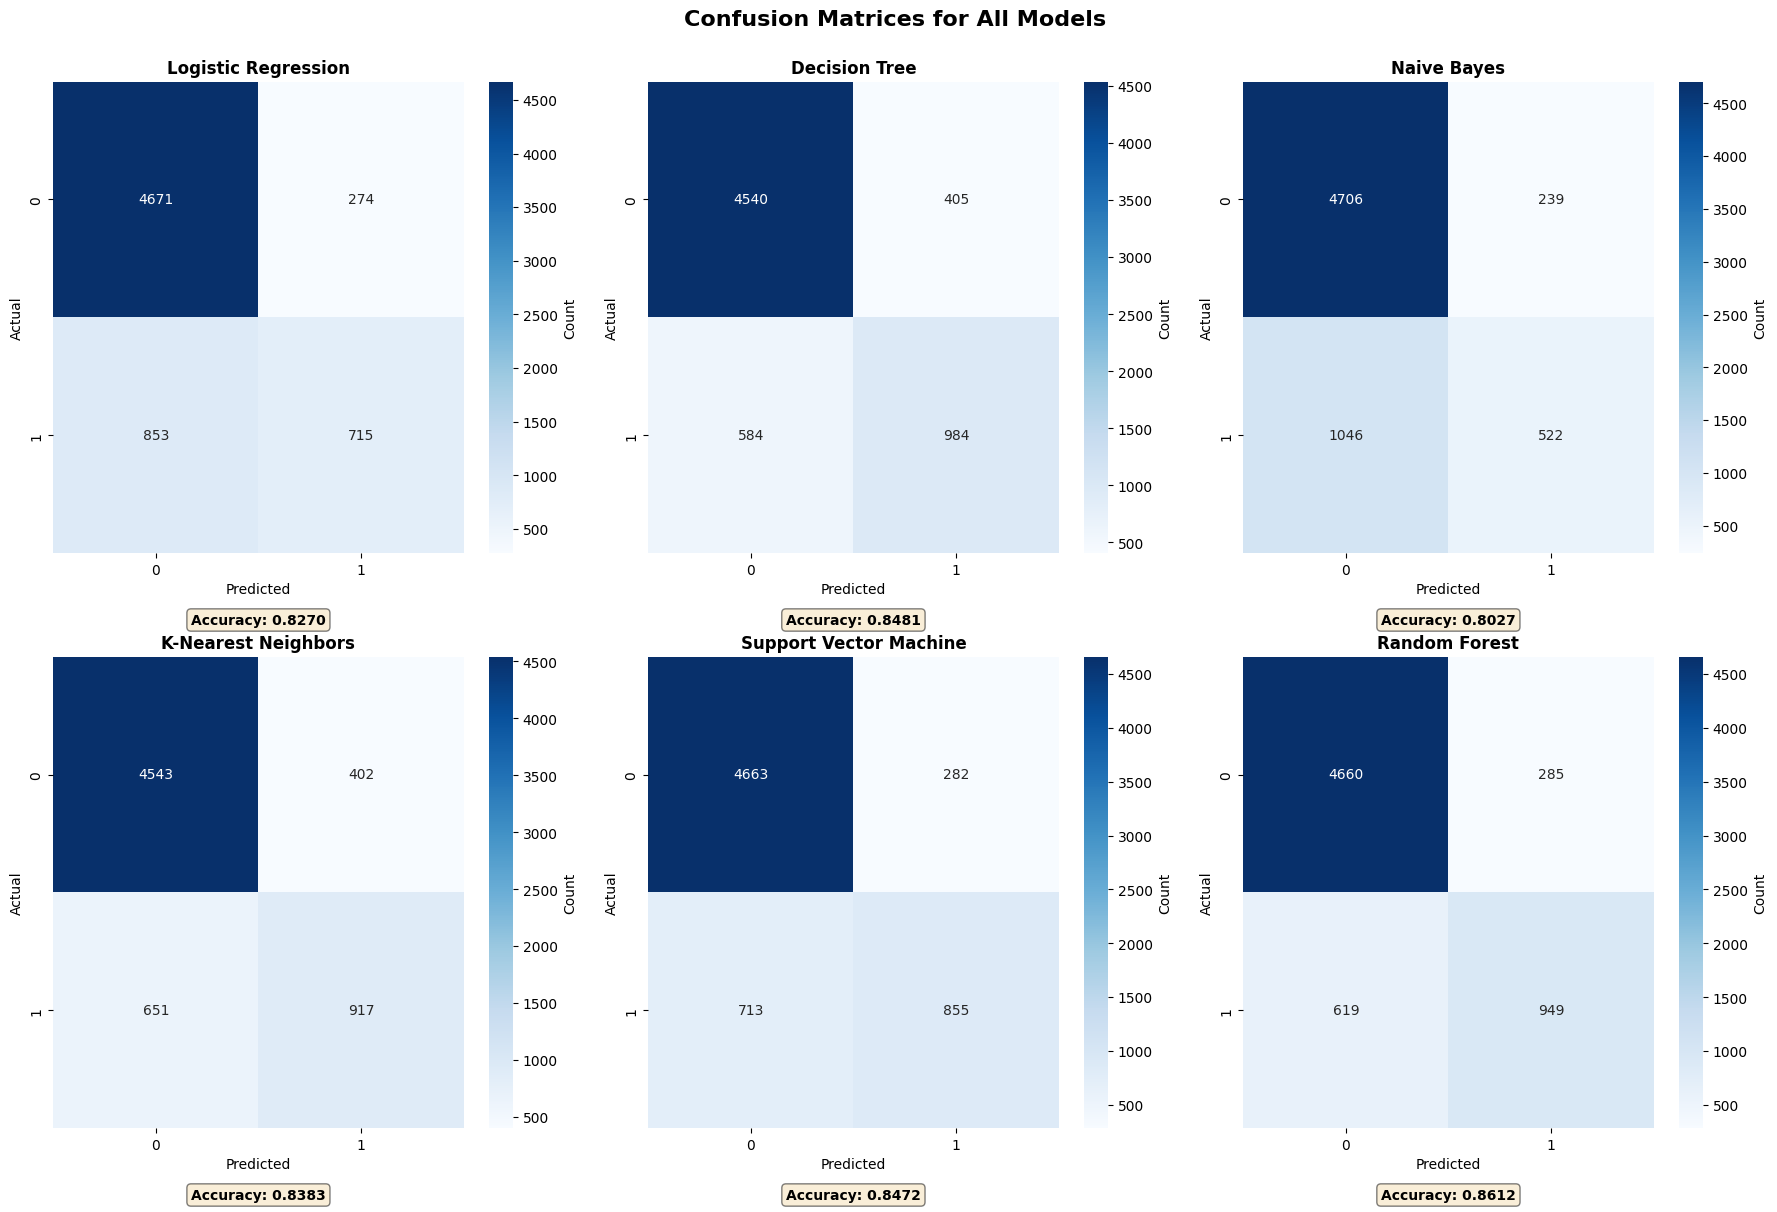

In [26]:
# Confusion matrices for all models (in a grid)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

models_predictions = [
    ('Logistic Regression', y_pred_lr),
    ('Decision Tree', y_pred_dt),
    ('Naive Bayes', y_pred_nb),
    ('K-Nearest Neighbors', y_pred_knn),
    ('Support Vector Machine', y_pred_svm),
    ('Random Forest', y_pred_rf)
]

for idx, (model_name, y_pred) in enumerate(models_predictions):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'{model_name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)
    
    # Add accuracy on the plot
    acc = accuracy_score(y_test, y_pred)
    axes[idx].text(0.5, -0.15, f'Accuracy: {acc:.4f}', 
                   transform=axes[idx].transAxes,
                   ha='center', fontsize=10, fontweight='bold',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Confusion Matrices for All Models', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

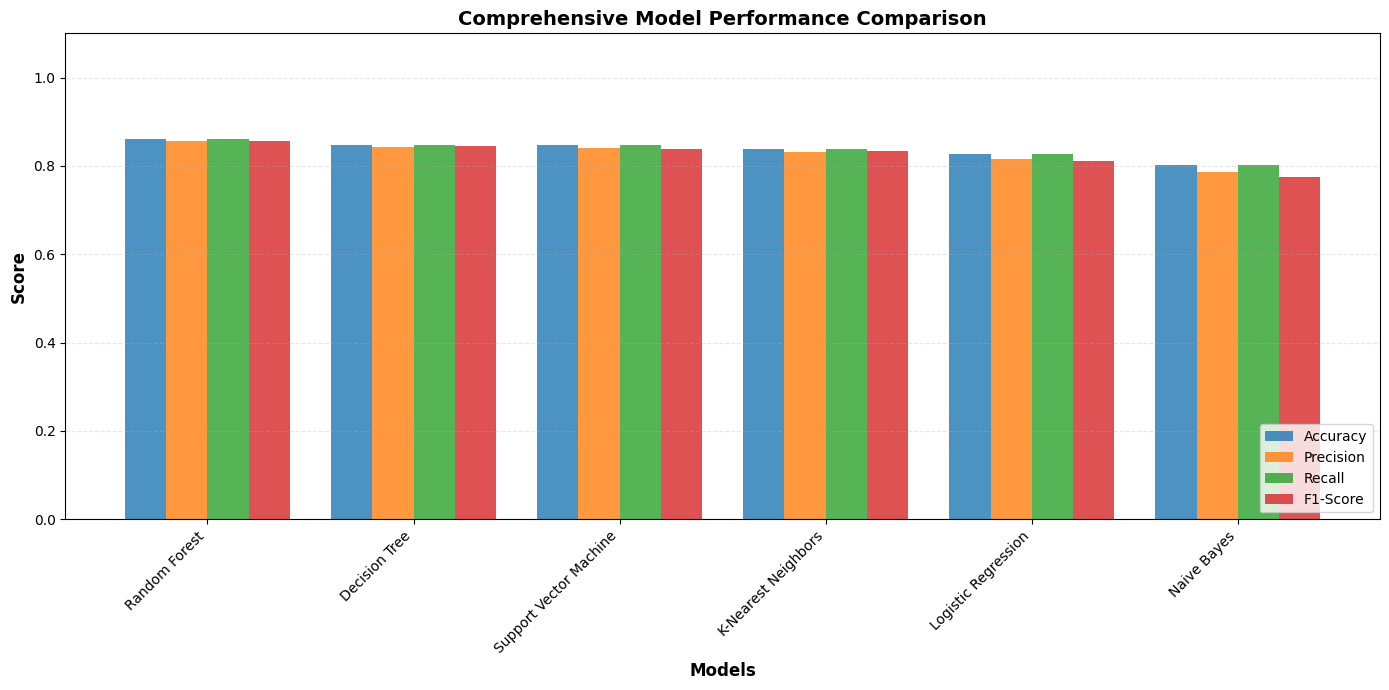

In [27]:
# Visualize all metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df['Model']))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 7))

for i, metric in enumerate(metrics):
    offset = width * (i - 1.5)
    ax.bar(x + offset, results_df[metric], width, label=metric, alpha=0.8)

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Comprehensive Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

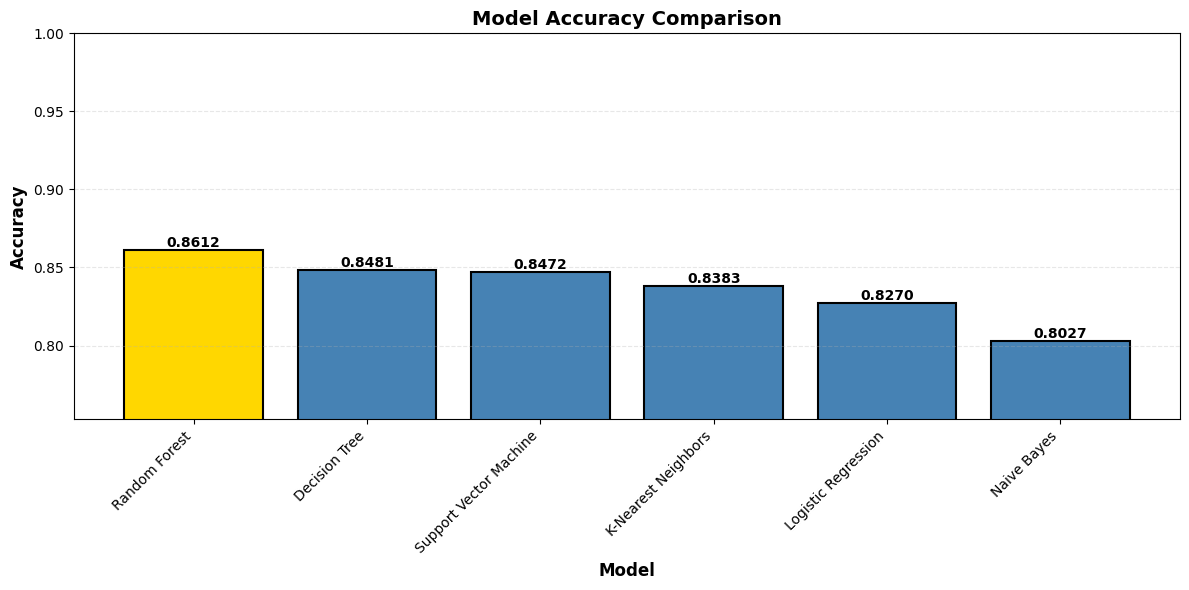

In [28]:
# Visualize model comparison - Accuracy
plt.figure(figsize=(12, 6))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
bars = plt.bar(results_df['Model'], results_df['Accuracy'], color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim([results_df['Accuracy'].min() - 0.05, 1.0])
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()